In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score    
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 

In [2]:
df = pd.read_csv('trans.csv')

In [3]:
df1 = df.copy()

In [4]:
df1.columns

Index(['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip',
       'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC',
       'Errors?', 'Is Fraud?'],
      dtype='object')

In [5]:
df1['Transaction_Timestamp']= pd.to_datetime(df1["Year"].astype(str) + '-' + df1["Month"].astype(str) + '-' + df1["Day"].astype(str) + ' ' + df1["Time"])

In [6]:
df1 = df1.sort_values(["User","Transaction_Timestamp"])
df1 = df1.reset_index(drop = True)

In [7]:
df1.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Transaction_Timestamp
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No,2002-09-01 06:21:00
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No,2002-09-01 06:42:00
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No,2002-09-02 06:22:00
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No,2002-09-02 17:45:00
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No,2002-09-03 06:23:00


In [8]:
# Remove dollar sign and convert to float
df1["Amount_numeric"] = df1["Amount"].replace('[\$,]', '', regex=True).astype(float)
df1["log_amount"] = np.log1p(df1["Amount_numeric"])

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
df1["is_chip"] = (df1["Use Chip"] == "Yes").astype(int)
df1["has_error"] = (df1["Errors?"] != "No").astype(int)

In [10]:
df1["hour"] = df1["Transaction_Timestamp"].dt.hour
df1["dayofweek"] = df1["Transaction_Timestamp"].dt.dayofweek

In [11]:
df1["time_since_prev_tx"] = (
    df1.groupby("User")["Transaction_Timestamp"].diff().dt.total_seconds()
)
df1["time_since_prev_tx"] = df1["time_since_prev_tx"].fillna(999999)

In [12]:
df1["tx_count_1h"] = (
    df1.groupby("User").rolling("1H", on="Transaction_Timestamp")["Amount"]
    .count().shift(1).reset_index(drop=True)
)

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/2912893391.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df1.groupby("User").rolling("1H", on="Transaction_Timestamp")["Amount"]
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/2912893391.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df1.groupby("User").rolling("1H", on="Transaction_Timestamp")["Amount"]


In [13]:
df1["tx_count_24h"] = (
    df1.groupby("User", group_keys=False)
    .apply(lambda x: x.rolling("24H", on="Transaction_Timestamp")["Amount"].count().shift(1))
)

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/1876071568.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.rolling("24H", on="Transaction_Timestamp")["Amount"].count().shift(1))
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/1876071568.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.rolling("24H", on="Transaction_Timestamp")["Amount"].count().shift(1))
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/1876071568.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply(lambda x: x.rolling("24H", on="Transaction_Timestamp")["Amount"].count().shift(1))
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/1876071568.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .apply

In [14]:
df1["user_median_amount"] = (
    df1.groupby("User")["Amount_numeric"].expanding().median().shift(1).reset_index(level=0, drop=True)
)

In [15]:
df1["amount_vs_user_median"] = (
    df1["Amount_numeric"] / (df1["user_median_amount"] + 1)
)

In [16]:
df1["is_new_mcc_for_user"] = (
    df1.groupby("User")["MCC"].transform(lambda x: x != x.shift(1)).astype(int)
)


In [17]:
df1["is_new_merchant_for_user"] = (
    ~df1.duplicated(subset=["User", "Merchant Name"])
).astype(int)

In [18]:
df1.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,has_error,hour,dayofweek,time_since_prev_tx,tx_count_1h,tx_count_24h,user_median_amount,amount_vs_user_median,is_new_mcc_for_user,is_new_merchant_for_user
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,...,1,6,6,999999.0,NaN,NaN,NaN,NaN,1,1
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,...,1,6,6,1260.0,1.0,1.0,134.090,0.284847,1,1
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,...,1,6,0,85200.0,2.0,2.0,86.285,1.378702,0,0
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,...,1,17,0,40980.0,1.0,2.0,120.340,1.062716,1,1
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,...,1,6,1,45480.0,1.0,2.0,124.645,0.833380,1,1


In [19]:
missing = df1.isna().mean().sort_values(ascending = False)
missing

Errors?                     9.840721e-01
Zip                         1.180197e-01
Merchant State              1.115690e-01
log_amount                  5.103232e-02
tx_count_24h                8.201124e-05
amount_vs_user_median       4.100562e-08
user_median_amount          4.100562e-08
tx_count_1h                 4.100562e-08
User                        0.000000e+00
Amount_numeric              0.000000e+00
is_new_mcc_for_user         0.000000e+00
time_since_prev_tx          0.000000e+00
dayofweek                   0.000000e+00
hour                        0.000000e+00
has_error                   0.000000e+00
is_chip                     0.000000e+00
Is Fraud?                   0.000000e+00
Transaction_Timestamp       0.000000e+00
Card                        0.000000e+00
MCC                         0.000000e+00
Merchant City               0.000000e+00
Merchant Name               0.000000e+00
Use Chip                    0.000000e+00
Amount                      0.000000e+00
Time            

In [20]:
df1["Is Fraud?"] = df1["Is Fraud?"].map({"No": 0, "Yes": 1}).astype(int)
df1["has_error"] = df1["has_error"].astype(int)

In [21]:
df1.groupby("has_error", observed=True)["Is Fraud?"].mean()

has_error
1    0.00122
Name: Is Fraud?, dtype: float64

In [22]:
df1.groupby("is_chip")["Is Fraud?"].mean()

is_chip
0    0.00122
Name: Is Fraud?, dtype: float64

In [23]:
df1.groupby("is_new_mcc_for_user")["Is Fraud?"].mean()

is_new_mcc_for_user
0    0.000499
1    0.001411
Name: Is Fraud?, dtype: float64

In [24]:
df1.groupby("is_new_merchant_for_user")["Is Fraud?"].mean()

is_new_merchant_for_user
0    0.000712
1    0.022648
Name: Is Fraud?, dtype: float64

In [25]:
baseline_features = [
    "log_amount","is_chip","has_error","hour","dayofweek","time_since_prev_tx",
    "tx_count_1h","tx_count_24h","amount_vs_user_median",
    "is_new_mcc_for_user","is_new_merchant_for_user"
]

X = df1[baseline_features].copy()
X["tx_count_1h"].fillna(0,inplace =True)
X["tx_count_24h"].fillna(0, inplace = True)
# X["amount_sum_24h"].fillna(0, inplace = True)  # This column does not exist
X["amount_vs_user_median"].fillna(1, inplace=True)

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/755563516.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["tx_count_1h"].fillna(0,inplace =True)
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_9005/755563516.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [26]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scale_cols = [
    "log_amount", "time_since_prev_tx", "tx_count_1h", "tx_count_24h", "amount_vs_user_median"
]

# Replace inf/-inf with nan, then fill nan with 0 (or another value if more appropriate)
X[scale_cols] = X[scale_cols].replace([np.inf, -np.inf], np.nan)
X[scale_cols] = X[scale_cols].fillna(0)

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

In [27]:
split_time = df1["Transaction_Timestamp"].quantile(0.8)
X_train = X[df1["Transaction_Timestamp"] <= split_time]
X_val = X[df1["Transaction_Timestamp"] > split_time]

y_train = df1.loc[X_train.index, "Is Fraud?"]
y_val = df1.loc[X_val.index,"Is Fraud?"]

In [28]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    penalty="l2", solver = "lbfgs", max_iter = 1000, class_weight= "balanced",
    n_jobs= -1
)


In [29]:
lr.fit(X_train,y_train)

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
y_val_proba = lr.predict_proba(X_val)[:,1]

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [31]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_val,y_val_proba)
pr_auc

0.010833649607567778

In [32]:
from sklearn.metrics import recall_score
threshold = 0.2
y_pred = (y_val_proba >= threshold).astype(int)
recall = recall_score(y_val, y_pred)
recall

0.8692323608524726

In [33]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_val, y_pred)

array([[1180790, 3691752],
       [    632,    4201]])

In [34]:
coef_df = pd.DataFrame(
    {
        "feature":X_train.columns, 
        "coefficient":lr.coef_[0]
    }
).sort_values(by = "coefficient", ascending=False)
coef_df

,feature,coefficient
10,is_new_merchant_for_user,3.376877
9,is_new_mcc_for_user,0.738279
0,log_amount,0.362959
7,tx_count_24h,0.242390
8,amount_vs_user_median,0.097671
4,dayofweek,0.068803
6,tx_count_1h,0.042598
1,is_chip,0.000000
3,hour,-0.087989
2,has_error,-0.310007


In [35]:
neg = (y_train == 0).sum()
pos = (y_train == 0).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(1.0)

In [36]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [37]:
lgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(30, verbose=50)]
)

[LightGBM] [Info] Number of positive: 24924, number of negative: 19484601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.155524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 841
[LightGBM] [Info] Number of data points in the train set: 19509525, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001278 -> initscore=-6.661549
[LightGBM] [Info] Start training from score -6.661549
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[6]	valid_0's average_precision: 0.0167296	valid_0's binary_logloss: 0.0075067


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [38]:
y_val_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

In [39]:
from sklearn.metrics import average_precision_score

pr_auc_lgb = average_precision_score(y_val, y_val_proba_lgb)
pr_auc_lgb

0.016729625976215086

In [40]:
threshold = 0.2
y_pred_lgb = (y_val_proba_lgb >= threshold).astype(int)

from sklearn.metrics import recall_score
recall_lgb = recall_score(y_val, y_pred_lgb)
recall_lgb

0.017794330643492656

In [41]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
3,hour,44
5,time_since_prev_tx,31
8,amount_vs_user_median,26
0,log_amount,25
7,tx_count_24h,19
4,dayofweek,10
6,tx_count_1h,9
9,is_new_mcc_for_user,8
10,is_new_merchant_for_user,8
1,is_chip,0


In [42]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(
objective="binary:logistic",
n_estimators=300,
learning_rate=0.05,
max_depth=6,
min_child_weight=100,
subsample=0.8,
colsample_bytree=0.8,
scale_pos_weight=scale_pos_weight,
eval_metric="aucpr",
random_state=42,
n_jobs=-1
)

In [43]:
xgb_model.fit(
X_train,
y_train,
eval_set=[(X_val, y_val)],
verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [44]:
from sklearn.metrics import average_precision_score


y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
pr_auc_xgb = average_precision_score(y_val, y_val_proba_xgb)
pr_auc_xgb

0.018363783184630427

In [45]:
from sklearn.metrics import recall_score
import numpy as np

for t in [0.01, 0.02, 0.05, 0.1]:
    y_pred = (y_val_proba_xgb >= t).astype(int)
    print(t, recall_score(y_val, y_pred))

0.01 0.3337471549762053
0.02 0.21953238154355473
0.05 0.10407614318228843
0.1 0.04531346989447548


In [46]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

xgb_importance.head(10)

,feature,importance
10,is_new_merchant_for_user,0.670996
5,time_since_prev_tx,0.077450
9,is_new_mcc_for_user,0.057820
8,amount_vs_user_median,0.048332
0,log_amount,0.037898
3,hour,0.034587
7,tx_count_24h,0.030303
6,tx_count_1h,0.025202
4,dayofweek,0.017413
1,is_chip,0.000000


In [47]:
from sklearn.metrics import precision_recall_curve
import pandas as pd
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba_lgb)

pr_df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall
})

pr_df.head()

,threshold,precision,recall
0,0.001026,0.000991,1.000000
1,0.001027,0.000995,0.998759
2,0.001028,0.001028,0.990689
3,0.001029,0.001029,0.989861
4,0.001030,0.001065,0.965239


In [48]:
def threshold_for_recall(pr_df, target_recall):
    eligible = pr_df[pr_df["recall"] >= target_recall]
    if len(eligible) == 0:
        return None
    return eligible.sort_values("precision", ascending=False).iloc[0]

targets = [0.9, 0.8, 0.7]

threshold_table = pd.DataFrame([
    {
        "target_recall": r,
        **threshold_for_recall(pr_df, r)
    }
    for r in targets
])

threshold_table

,target_recall,threshold,precision,recall
0,0.9,0.001051,0.001296,0.900269
1,0.8,0.001102,0.001845,0.802607
2,0.7,0.001156,0.002717,0.702462


In [49]:
from sklearn.metrics import confusion_matrix

def metrics_at_threshold(th):
    y_pred = (y_val_proba_lgb >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    return {
        "threshold": th,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "recall": tp / (tp + fn),
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0
    }

metrics_df = pd.DataFrame([
    metrics_at_threshold(row["threshold"])
    for _, row in threshold_table.iterrows()
])

metrics_df

,threshold,TP,FP,FN,TN,recall,precision
0,0.001051,4351,3354092,482,1518450,0.900269,0.001296
1,0.001102,3879,2098065,954,2774477,0.802607,0.001845
2,0.001156,3395,1246003,1438,3626539,0.702462,0.002717


In [50]:
import shap

# Use TreeExplainer for LightGBM
explainer = shap.TreeExplainer(lgb_model)

# Sample for speed (VERY IMPORTANT on large data)
X_val_sample = X_val.sample(n=10000, random_state=42)

shap_values = explainer.shap_values(X_val_sample)

/opt/homebrew/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


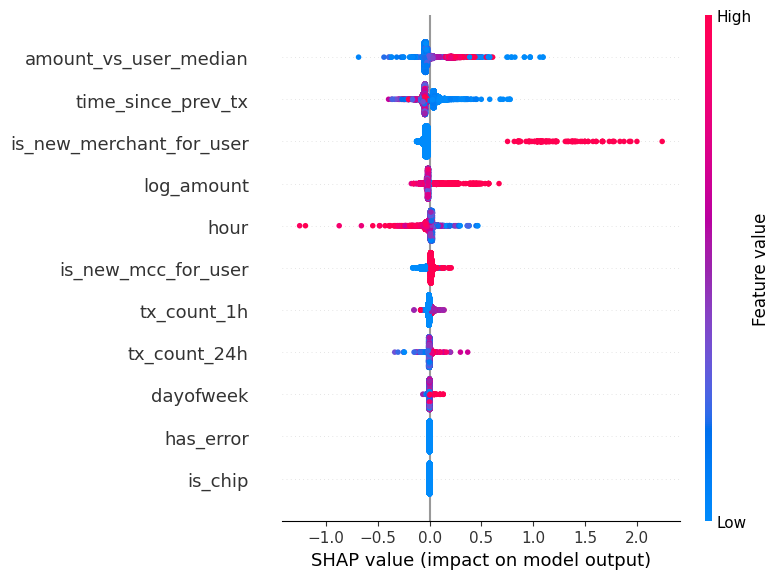

In [51]:
shap.summary_plot(shap_values, X_val_sample)

In [52]:
shap_importance = pd.DataFrame({
    "feature": X_val_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
8,amount_vs_user_median,0.062135
5,time_since_prev_tx,0.062079
10,is_new_merchant_for_user,0.054076
0,log_amount,0.032736
3,hour,0.025177
9,is_new_mcc_for_user,0.025002
6,tx_count_1h,0.011693
7,tx_count_24h,0.007700
4,dayofweek,0.002784
1,is_chip,0.000000


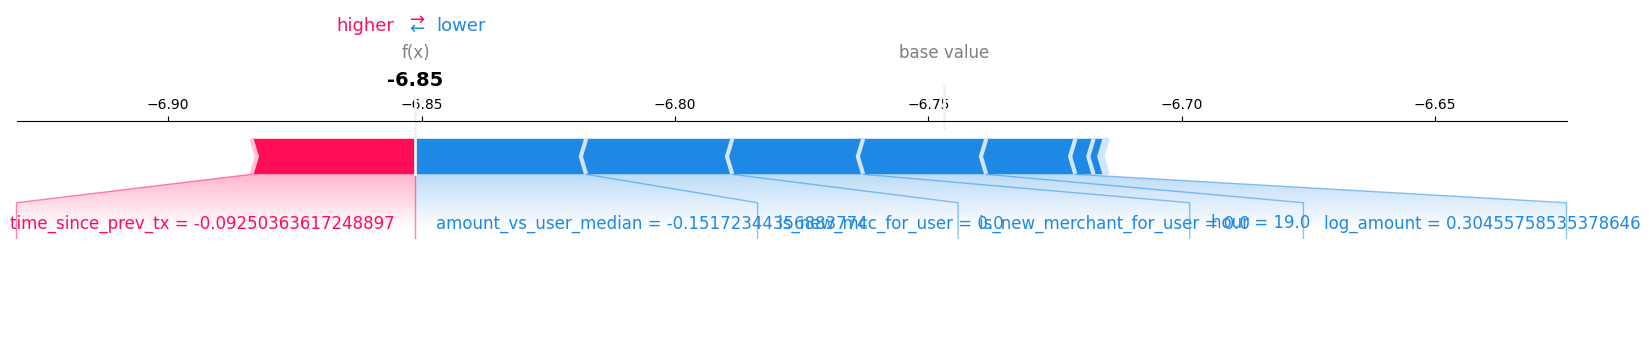

In [53]:
# Pick a high-risk transaction
idx = X_val_sample.index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[X_val_sample.index.get_loc(idx)],
    X_val_sample.loc[idx],
    matplotlib=True
)

In [54]:
# ---- FRAUD TRANSACTION OUTPUT TABLE ----

fraud_tx = df1.loc[X_val.index, [
    "User",
    "Merchant Name",
    "Year", "Month", "Day", "Time",
    "is_new_merchant_for_user",
    "is_new_mcc_for_user",
    "tx_count_24h",
    "time_since_prev_tx",
    "amount_vs_user_median",
    "Is Fraud?"
]].copy()

# Add fraud score
fraud_tx["fraud_score"] = y_val_proba_lgb

In [56]:
T1 = 0.00105  # Critical
T2 = 0.00110  # High
T3 = 0.00116  # Medium

# Bins must be in increasing order, so:
# [0, T1, T2, T3, 1.0] with corresponding labels
fraud_tx["fraud_band"] = pd.cut(
    fraud_tx["fraud_score"],
    bins=[0, T1, T2, T3, 1.0],
    labels=["Critical", "High", "Medium", "Low"],
    include_lowest=True
)

In [57]:
fraud_tx["fraud_action"] = fraud_tx["fraud_band"].map({
    "Critical": "Decline",
    "High": "OTP",
    "Medium": "Monitor",
    "Low": "Approve"
})

In [58]:
fraud_tx.to_csv(
    "fraud_transaction_output_lightgbm.csv",
    index=False
)